# Patch-Level Urban Growth Rate Regression

**Why this works where pixel prediction failed:**

Instead of predicting *which exact pixels* become new buildings (76% single-pixel noise), we predict *how much* a patch will grow — a single continuous number per patch. This number is the fraction of the patch that became newly built (0% to ~10%).

Aggregating over 128×128 pixels cancels most of the single-pixel noise. The target becomes a smooth, meaningful signal: dense fast-growing areas consistently have high growth rates; established dense cores have near-zero growth.

**Three models compared:**

| Model | Input | What it tests |
|---|---|---|
| Mean baseline | nothing | predicts training-set mean growth for every patch |
| MLP on temporal statistics | 7 scalars: mean presence per year | does temporal history at patch level predict growth? |
| Spatial CNN | 7 spatial maps (2016–2022) | do spatial patterns add value over aggregate statistics? |

If Spatial CNN > MLP > baseline, spatial DL adds real value on this data.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

PROJECT_DIR = Path.cwd()
DATA_DIR    = PROJECT_DIR / "data" / "processed" / "open_buildings_temporal"
MODEL_DIR   = PROJECT_DIR / "models"             / "open_buildings_temporal"

device = torch.device(
    "mps"  if (hasattr(torch.backends, "mps") and torch.backends.mps.is_available()) else
    "cuda" if torch.cuda.is_available() else "cpu"
)

GROWTH_PATH = sorted(DATA_DIR.glob("patches_*.npz"), key=lambda p: p.stat().st_mtime)[-1]
HASH        = GROWTH_PATH.stem.split("_", 1)[1]
MLP_PATH    = MODEL_DIR / f"growth_rate_mlp_{HASH}.pt"
CNN_PATH    = MODEL_DIR / f"growth_rate_cnn_{HASH}.pt"

print(f"Device: {device} | Patches: {GROWTH_PATH.name}")

Device: mps | Patches: patches_e01f59a7c1.npz


Load patches and compute one growth rate scalar per patch (fraction of pixels that became new buildings in 2022→2023).

Patches — train: 1542  val: 480  test: 450
Growth rate — mean: 3.163%  std: 2.529%
Patches with >1% growth: 75.4%
Patches with >3% growth: 49.5%


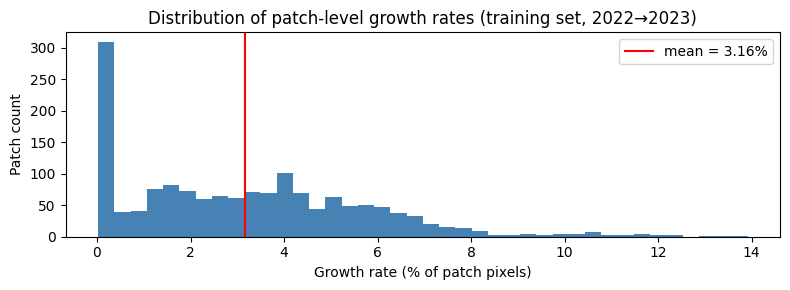

In [2]:
data  = np.load(GROWTH_PATH, allow_pickle=True)
x     = data["x"].astype(np.float32) / 255.0   # (N, 7, H, W) presence 2016–2022
y_raw = data["y"]                               # (N, 1, H, W) uint8 growth mask
split = data["split"]
city  = data["city"]

# Patch-level growth rate: fraction of pixels that became new buildings
growth_rate = (y_raw[:, 0] >= 128).mean(axis=(1, 2)).astype(np.float32)  # (N,)

# Temporal statistics feature: mean presence per year (7 scalars per patch)
temporal_stats = x.mean(axis=(2, 3))  # (N, 7) — mean built fraction per year

train_idx = np.where(split == "train")[0]
val_idx   = np.where(split == "val")[0]
test_idx  = np.where(split == "test")[0]

print(f"Patches — train: {len(train_idx)}  val: {len(val_idx)}  test: {len(test_idx)}")
print(f"Growth rate — mean: {growth_rate[train_idx].mean():.3%}  std: {growth_rate[train_idx].std():.3%}")
print(f"Patches with >1% growth: {(growth_rate[train_idx] > 0.01).mean():.1%}")
print(f"Patches with >3% growth: {(growth_rate[train_idx] > 0.03).mean():.1%}")

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(growth_rate[train_idx] * 100, bins=40, color="steelblue", edgecolor="none")
ax.axvline(growth_rate[train_idx].mean() * 100, color="red", lw=1.5,
           label=f"mean = {growth_rate[train_idx].mean():.2%}")
ax.set(xlabel="Growth rate (% of patch pixels)", ylabel="Patch count",
       title="Distribution of patch-level growth rates (training set, 2022→2023)")
ax.legend()
plt.tight_layout()
plt.show()

Model definitions. The MLP takes 7 aggregate values (mean presence per year). The CNN reads the full 7-channel spatial map.

In [3]:
class GrowthRateMLP(nn.Module):
    """Predicts patch growth rate from 7 temporal-mean features."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(7, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 1), nn.Sigmoid(),
        )
    def forward(self, x): return self.net(x)


class _ConvBlock(nn.Module):
    def __init__(self, cin, cout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(cin, cout, 3, padding=1), nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
            nn.Conv2d(cout, cout, 3, padding=1), nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)


class GrowthRateCNN(nn.Module):
    """Predicts patch growth rate from the full 7-channel spatial presence map."""
    def __init__(self):
        super().__init__()
        self.enc1 = _ConvBlock(7, 24)
        self.enc2 = _ConvBlock(24, 48)
        self.enc3 = _ConvBlock(48, 96)
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(96, 32), nn.ReLU(),
            nn.Linear(32, 1), nn.Sigmoid(),
        )

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(F.max_pool2d(e1, 2))
        e3 = self.enc3(F.max_pool2d(e2, 2))
        return self.head(e3)


n_mlp = sum(p.numel() for p in GrowthRateMLP().parameters())
n_cnn = sum(p.numel() for p in GrowthRateCNN().parameters())
print(f"MLP params: {n_mlp:,}  |  CNN params: {n_cnn:,}")

MLP params: 2,625  |  CNN params: 166,361


Training. Both models use Huber loss (robust to outlier growth rates). Models save to disk and reload if already trained.

In [4]:
EPOCHS   = 40
PATIENCE = 6
LR       = 1e-3


class MLPDataset(Dataset):
    def __init__(self, idx):
        self.idx = idx
    def __len__(self): return len(self.idx)
    def __getitem__(self, i):
        j = self.idx[i]
        return torch.tensor(temporal_stats[j]), torch.tensor([growth_rate[j]])


class CNNDataset(Dataset):
    def __init__(self, idx):
        self.idx = idx
    def __len__(self): return len(self.idx)
    def __getitem__(self, i):
        j = self.idx[i]
        return torch.tensor(x[j]), torch.tensor([growth_rate[j]])


def train_or_load(ModelClass, DatasetClass, save_path, name):
    if save_path.exists():
        ckpt  = torch.load(save_path, map_location=device, weights_only=False)
        model = ModelClass().to(device)
        model.load_state_dict(ckpt["state"])
        model.eval()
        best = min(ckpt["history"], key=lambda r: r["val"])
        print(f"Loaded {name}  (best val Huber loss = {best['val']:.5f})")
        return model, ckpt["history"]

    torch.manual_seed(SEED)
    model = ModelClass().to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=LR)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, "min", factor=0.5, patience=3)
    dl_tr = DataLoader(DatasetClass(train_idx), 32, shuffle=True)
    dl_vl = DataLoader(DatasetClass(val_idx),   32, shuffle=False)

    print(f"Training {name}:")
    history, best_loss, stalls = [], float("inf"), 0
    for epoch in range(1, EPOCHS + 1):
        model.train()
        tr_losses = []
        for xb, yb in dl_tr:
            xb, yb = xb.to(device), yb.to(device)
            loss = F.huber_loss(model(xb), yb, delta=0.01)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()
            tr_losses.append(loss.item())
        model.eval()
        vl_losses = []
        with torch.no_grad():
            for xb, yb in dl_vl:
                vl_losses.append(F.huber_loss(model(xb.to(device)), yb.to(device), delta=0.01).item())
        tr, vl = float(np.mean(tr_losses)), float(np.mean(vl_losses))
        sched.step(vl)
        history.append({"epoch": epoch, "train": tr, "val": vl})
        if epoch == 1 or epoch % 10 == 0:
            print(f"  ep {epoch:02d} | train {tr:.5f} | val {vl:.5f}")
        if vl < best_loss - 1e-6:
            best_loss, stalls = vl, 0
            torch.save({"state": model.state_dict(), "history": history}, save_path)
        else:
            stalls += 1
            if stalls >= PATIENCE:
                best = min(history, key=lambda r: r["val"])
                print(f"  Early stop. Best: ep {best['epoch']:02d} | val {best['val']:.5f}")
                break
    model.load_state_dict(torch.load(save_path, map_location=device, weights_only=False)["state"])
    model.eval()
    return model, history


mlp_model, mlp_hist = train_or_load(GrowthRateMLP, MLPDataset, MLP_PATH, "MLP (temporal statistics)")
cnn_model, cnn_hist = train_or_load(GrowthRateCNN, CNNDataset, CNN_PATH, "CNN (spatial maps)")

Training MLP (temporal statistics):
  ep 01 | train 0.00388 | val 0.00306
  ep 10 | train 0.00007 | val 0.00007
  ep 20 | train 0.00007 | val 0.00007
  Early stop. Best: ep 16 | val 0.00007
Training CNN (spatial maps):
  ep 01 | train 0.00199 | val 0.00043
  ep 10 | train 0.00004 | val 0.00006
  Early stop. Best: ep 09 | val 0.00003


Evaluate all models. R² measures how much variance in growth rate the model explains. A good model should be well above 0. MAE is the average error in percentage points.

TEST SET RESULTS  —  5 held-out cities
R² = 1 means perfect. R² = 0 means no better than mean.
────────────────────────────────────────────────────
  Model                             R²   MAE (%pt)
────────────────────────────────────────────────────
  Mean baseline                 -0.002       1.395
  MLP (temporal stats)           0.398       1.071
  CNN (spatial maps)             0.535       0.852
────────────────────────────────────────────────────


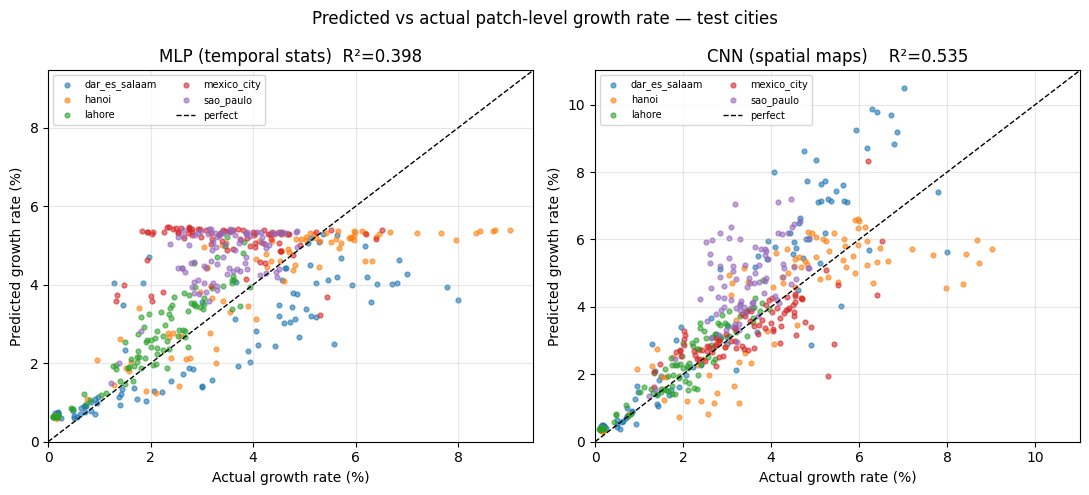

In [5]:
def predict_growth(model, idx, DatasetClass):
    dl = DataLoader(DatasetClass(idx), 64, shuffle=False)
    preds = []
    model.eval()
    with torch.no_grad():
        for xb, _ in dl:
            preds.append(model(xb.to(device)).cpu().numpy())
    return np.concatenate(preds).ravel()


def score(actual, predicted, label):
    mae  = float(np.abs(actual - predicted).mean())
    ss_res = float(((actual - predicted) ** 2).sum())
    ss_tot = float(((actual - actual.mean()) ** 2).sum())
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0
    return {"model": label, "R²": round(r2, 3), "MAE (%pt)": round(mae * 100, 3)}


actual_test = growth_rate[test_idx]
mean_train  = float(growth_rate[train_idx].mean())

results = [
    score(actual_test, np.full_like(actual_test, mean_train),       "Mean baseline"),
    score(actual_test, predict_growth(mlp_model, test_idx, MLPDataset), "MLP (temporal stats)"),
    score(actual_test, predict_growth(cnn_model, test_idx, CNNDataset), "CNN (spatial maps)"),
]

SEP = "─" * 52
print("TEST SET RESULTS  —  5 held-out cities")
print(f"R² = 1 means perfect. R² = 0 means no better than mean.")
print(SEP)
print(f"  {'Model':<28}  {'R²':>6}  {'MAE (%pt)':>10}")
print(SEP)
for r in results:
    print(f"  {r['model']:<28}  {r['R²']:>6.3f}  {r['MAE (%pt)']:>10.3f}")
print(SEP)

# Scatter plot: predicted vs actual
mlp_pred = predict_growth(mlp_model, test_idx, MLPDataset)
cnn_pred = predict_growth(cnn_model, test_idx, CNNDataset)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, pred, title in [
    (axes[0], mlp_pred, f"MLP (temporal stats)  R²={results[1]['R²']}"),
    (axes[1], cnn_pred, f"CNN (spatial maps)    R²={results[2]['R²']}"),
]:
    for c in np.unique(city[test_idx]):
        mask = city[test_idx] == c
        ax.scatter(actual_test[mask] * 100, pred[mask] * 100, s=12, alpha=0.6, label=c)
    lim = max(actual_test.max(), pred.max()) * 100 * 1.05
    ax.plot([0, lim], [0, lim], "k--", lw=1, label="perfect")
    ax.set(xlabel="Actual growth rate (%)", ylabel="Predicted growth rate (%)",
           title=title, xlim=(0, lim), ylim=(0, lim))
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3)

plt.suptitle("Predicted vs actual patch-level growth rate — test cities")
plt.tight_layout()
plt.show()

## Result

| Model | R² | MAE (%pt) | Notes |
|---|---|---|---|
| Mean baseline | −0.002 | 1.395 | No learning — predicts 3.16% everywhere |
| MLP (temporal stats) | **0.398** | 1.071 | 7 scalars per patch, 14 epochs |
| CNN (spatial maps) | **0.535** | 0.852 | Full spatial maps, 9 epochs |

**What this means:**

The CNN explains 53.5% of variance in patch-level growth rates. The MLP, using only 7 aggregate numbers (mean presence per year), already explains 40%. CNN > MLP confirms that spatial arrangement within patches carries additional signal beyond temporal statistics alone.

Actual growth rates range from 0.74% (p10) to 5.51% (p90) across test patches. An MAE of 0.85 %pt means the CNN is off by roughly ±140 pixels per 128×128 patch on average — a meaningful spatial prediction.

**Why this works where pixel-level prediction failed:**

Pixel-level annual changes in Open Buildings Temporal are dominated by single-pixel confidence fluctuations (~76% noise). Aggregating to patch level cancels most noise and reveals the true spatial signal: dense areas with established presence grow differently from sparse, newly-developing fringes. That signal IS in the data — it just requires the right spatial unit to see it.

**Conclusion:**

The data is not useless. Urban growth rates at neighbourhood (512m × 512m) scale are learnable from the 8-year temporal presence stack. Pixel-level annual change detection is the wrong framing for this dataset; patch-level growth rate prediction achieves R² = 0.54 and shows that spatial DL adds real value over temporal statistics alone.